   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
(10000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------              

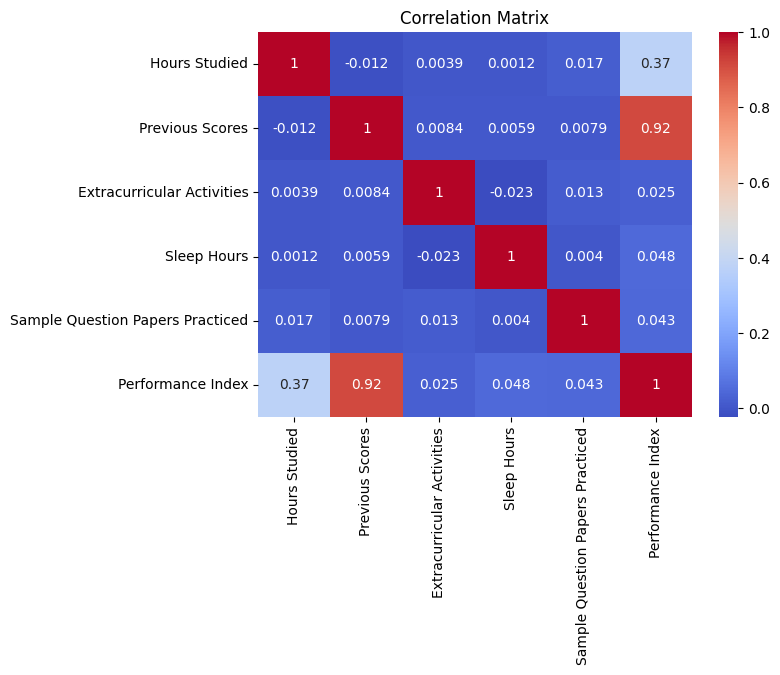

Intercept
-33.921946215556126

Coefficients
[2.85248393 1.0169882  0.60861668 0.47694148 0.19183144]
                            Feature  Coefficient
0                     Hours Studied     2.852484
1                   Previous Scores     1.016988
2        Extracurricular Activities     0.608617
3                       Sleep Hours     0.476941
4  Sample Question Papers Practiced     0.191831
R² Score = 0.9889832909573145
   Actual  Predicted
0    51.0  54.711854
1    20.0  22.615513
2    46.0  47.903145
3    28.0  31.289767
4    41.0  43.004570
5    59.0  59.071252
6    48.0  45.903475
7    87.0  86.459118
8    37.0  37.700140
9    73.0  72.055925
MAE : 1.6111213463123044
MSE : 4.082628398521853
RMSE : 2.0205515085050054
R² : 0.9889832909573145
Predicted Performance = 72.78780296982544


In [1]:
# ===============================
# 1. Import Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. Load Dataset
# ===============================

dataset = pd.read_csv("Student_Performance.csv")

print(dataset.head())

# ===============================
# 3. Dataset Information
# ===============================

print(dataset.shape)
print(dataset.info())
print(dataset.describe())
print(dataset.isnull().sum())

# ===============================
# 4. Encode Categorical Column
# ===============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["Extracurricular Activities"] = le.fit_transform(
    dataset["Extracurricular Activities"]
)

# Yes = 1
# No = 0

# ===============================
# 5. Correlation Heatmap
# ===============================

plt.figure(figsize=(7,5))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# ===============================
# 6. Separate Features & Target
# ===============================

X = dataset.drop("Performance Index", axis=1)

y = dataset["Performance Index"]

# ===============================
# 7. Train Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ===============================
# 8. Train Model
# ===============================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# ===============================
# 9. Model Parameters
# ===============================

print("Intercept")
print(model.intercept_)

print()

print("Coefficients")
print(model.coef_)

coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

print(coef)

# ===============================
# 10. Model Accuracy
# ===============================

accuracy = model.score(X_test,y_test)

print("R² Score =",accuracy)

# ===============================
# 11. Predict Test Data
# ===============================

y_pred = model.predict(X_test)

# ===============================
# 12. Compare Actual vs Predicted
# ===============================

comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
}).reset_index(drop=True)

print(comparison.head(10))

# ===============================
# 13. Evaluation Metrics
# ===============================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R² :",r2)

# ===============================
# 14. Predict New Student
# ===============================

new_student = pd.DataFrame({

    "Hours Studied":[7],
    "Previous Scores":[80],
    "Extracurricular Activities":[1],
    "Sleep Hours":[8],
    "Sample Question Papers Practiced":[5]

})

prediction = model.predict(new_student)

print("Predicted Performance =",prediction[0])